# Streaming Cord Cutting Analysis

Companion notebook to "When Cutting the Cord Just Braided You a New One" on [TheDraft]((https://thedrafthq.substack.com). The pitch of streaming was: pay less than cable, watch what you want, no ads. This notebook checks whether that pitch still holds in 2026.

## Methodology

Pricing data was compiled manually from press releases, contemporary news coverage, and current pricing pages. Each price point includes a source note in the `source` column of the dataset. The ad-free tier was used for each service to enable apples-to-apples comparison across services and over time. For Peacock, the Premium Plus tier was used as the ad-free reference (ads still play on live content even on this tier — a relevant nuance not captured in the price alone).

For each service, the earliest price in the dataset (launch year or 2019, whichever was earlier) was compared to the most recent confirmed price as of May 2026. The "full bundle" calculation sums the most recent price for each service that existed by a given year, capturing both per-service price hikes and the cumulative cost of fragmentation as new services launched.

Inflation comparison uses cumulative US CPI inflation from 2019 to 2026: approximately 30.26%.

In [13]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# style settings for charts later
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200

print("setup complete")

setup complete


In [14]:
# step 1: price history data with verified sources
# US ad-free tier pricing for seven major streaming services, 2019 - May 2026
# each row's `source` field links to the source for that specific price point

price_history = [
    # NETFLIX (Standard tier, ad-free)
    {"service": "Netflix", "year": 2019, "tier": "Standard", "price": 12.99, "source": "https://flixed.io/netflix-price-hikes"},
    {"service": "Netflix", "year": 2020, "tier": "Standard", "price": 13.99, "source": "https://flixed.io/netflix-price-hikes"},
    {"service": "Netflix", "year": 2022, "tier": "Standard", "price": 15.49, "source": "https://flixed.io/netflix-price-hikes"},
    {"service": "Netflix", "year": 2025, "tier": "Standard", "price": 17.99, "source": "https://flixed.io/netflix-price-hikes"},
    {"service": "Netflix", "year": 2026, "tier": "Standard", "price": 19.99, "source": "https://help.netflix.com/en/node/24926"},

    # DISNEY+ (ad-free tier)
    {"service": "Disney+", "year": 2019, "tier": "Standard", "price": 6.99, "source": "https://variety.com/2019/digital/news/disney-plus-streaming-launch-date-pricing-1203187007/"},
    {"service": "Disney+", "year": 2021, "tier": "Standard", "price": 7.99, "source": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://agoodmovietowatch.com/the-complete-history-of-disney-price-hikes/&ved=2ahUKEwiVr6vfztOUAxXRLFkFHR_TOIQQFnoECBoQAQ&usg=AOvVaw1K7rvHKmiOAOG9CXaNs5a2$0"},
    {"service": "Disney+", "year": 2022, "tier": "Standard", "price": 10.99, "source": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://agoodmovietowatch.com/the-complete-history-of-disney-price-hikes/&ved=2ahUKEwiVr6vfztOUAxXRLFkFHR_TOIQQFnoECBoQAQ&usg=AOvVaw1K7rvHKmiOAOG9CXaNs5a2$0"},
    {"service": "Disney+", "year": 2023, "tier": "Standard", "price": 13.99, "source": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://agoodmovietowatch.com/the-complete-history-of-disney-price-hikes/&ved=2ahUKEwiVr6vfztOUAxXRLFkFHR_TOIQQFnoECBoQAQ&usg=AOvVaw1K7rvHKmiOAOG9CXaNs5a2$0"},
    {"service": "Disney+", "year": 2024, "tier": "Standard", "price": 15.99, "source": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://agoodmovietowatch.com/the-complete-history-of-disney-price-hikes/&ved=2ahUKEwiVr6vfztOUAxXRLFkFHR_TOIQQFnoECBoQAQ&usg=AOvVaw1K7rvHKmiOAOG9CXaNs5a2$0"},
    {"service": "Disney+", "year": 2026, "tier": "Standard", "price": 18.99, "source": "https://help.disneyplus.com/article/disneyplus-price#standalone"},

    # HULU (ad-free)
    {"service": "Hulu", "year": 2019, "tier": "No Ads", "price": 11.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hulu-with-live-tv-price-hikes/"},
    {"service": "Hulu", "year": 2022, "tier": "No Ads", "price": 14.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hulu-with-live-tv-price-hikes/"},
    {"service": "Hulu", "year": 2023, "tier": "No Ads", "price": 17.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hulu-with-live-tv-price-hikes/"},
    {"service": "Hulu", "year": 2024, "tier": "No Ads", "price": 18.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hulu-with-live-tv-price-hikes/"},
    {"service": "Hulu", "year": 2026, "tier": "No Ads", "price": 18.99, "source": "https://help.hulu.com/article/hulu-how-much-does-hulu-cost"},

    # HBO MAX / MAX (ad-free)
    {"service": "HBO Max/Max", "year": 2020, "tier": "Ad-Free", "price": 14.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hbo-max-price-hikes/"},
    {"service": "HBO Max/Max", "year": 2023, "tier": "Ad-Free", "price": 15.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hbo-max-price-hikes/"},
    {"service": "HBO Max/Max", "year": 2024, "tier": "Ad-Free", "price": 16.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-hbo-max-price-hikes/"},
    {"service": "HBO Max/Max", "year": 2026, "tier": "Ad-Free", "price": 18.49, "source": "https://help.hbomax.com/us/Answer/Detail/000002547"},

    # PARAMOUNT+
    {"service": "Paramount+", "year": 2021, "tier": "Premium", "price": 9.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-paramount-price-hikes/"},
    {"service": "Paramount+", "year": 2023, "tier": "with Showtime", "price": 11.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-paramount-price-hikes/"},
    {"service": "Paramount+", "year": 2024, "tier": "with Showtime", "price": 12.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-paramount-price-hikes/"},
    {"service": "Paramount+", "year": 2026, "tier": "with Showtime", "price": 13.99, "source": "https://www.paramountplus.com/account/signup/pickplan/"},

    # APPLE TV+
    {"service": "Apple TV+", "year": 2019, "tier": "Standard", "price": 4.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-apple-tv-price-hikes/"},
    {"service": "Apple TV+", "year": 2022, "tier": "Standard", "price": 6.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-apple-tv-price-hikes/"},
    {"service": "Apple TV+", "year": 2023, "tier": "Standard", "price": 9.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-apple-tv-price-hikes/"},
    {"service": "Apple TV+", "year": 2026, "tier": "Standard", "price": 12.99, "source": "https://agoodmovietowatch.com/the-complete-history-of-apple-tv-price-hikes/"},

    # PEACOCK
    {"service": "Peacock", "year": 2020, "tier": "Premium Plus", "price": 9.99, "source": "https://www.theverge.com/2020/1/16/21068607/nbc-peacock-streaming-service-price-launch-date-ads-universal-comcast-office-harry-potter"},
    {"service": "Peacock", "year": 2023, "tier": "Premium Plus", "price": 11.99, "source": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://agoodmovietowatch.com/the-complete-history-of-peacock-price-hikes/&ved=2ahUKEwiVxor7ztOUAxUkD1kFHazkKJAQFnoECCEQAQ&usg=AOvVaw30hk_J5zlwdW6mAXlYS1OI$0"},
    {"service": "Peacock", "year": 2024, "tier": "Premium Plus", "price": 13.99, "source": "https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://agoodmovietowatch.com/the-complete-history-of-peacock-price-hikes/&ved=2ahUKEwiVxor7ztOUAxUkD1kFHazkKJAQFnoECCEQAQ&usg=AOvVaw30hk_J5zlwdW6mAXlYS1OI$0"},
    {"service": "Peacock", "year": 2026, "tier": "Premium Plus", "price": 16.99, "source": "https://www.peacocktv.com/plans/all-monthly"},
]

df = pd.DataFrame(price_history)
df

,service,year,tier,price,source
0,Netflix,2019,Standard,12.99,https://flixed.io/netflix-price-hikes
1,Netflix,2020,Standard,13.99,https://flixed.io/netflix-price-hikes
2,Netflix,2022,Standard,15.49,https://flixed.io/netflix-price-hikes
3,Netflix,2025,Standard,17.99,https://flixed.io/netflix-price-hikes
4,Netflix,2026,Standard,19.99,https://help.netflix.com/en/node/24926
5,Disney+,2019,Standard,6.99,https://variety.com/2019/digital/news/disney-p...
6,Disney+,2021,Standard,7.99,https://www.google.com/url?sa=t&source=web&rct...
7,Disney+,2022,Standard,10.99,https://www.google.com/url?sa=t&source=web&rct...
8,Disney+,2023,Standard,13.99,https://www.google.com/url?sa=t&source=web&rct...
9,Disney+,2024,Standard,15.99,https://www.google.com/url?sa=t&source=web&rct...


In [15]:
# step 2A: per-service price changes
# for each service, find the earliest price (launch or 2019) and the latest price,
# then calculate dollar and percent increase

# earliest price per service
earliest = df.loc[df.groupby('service')['year'].idxmin()].rename(
    columns={'year': 'start_year', 'price': 'start_price'}
)[['service', 'start_year', 'start_price']]

# most recent price per service
latest = df.loc[df.groupby('service')['year'].idxmax()].rename(
    columns={'year': 'end_year', 'price': 'end_price'}
)[['service', 'end_year', 'end_price']]

# merge for side-by-side comparison
comparison = earliest.merge(latest, on='service')

# calculate increases
comparison['dollar_increase'] = (comparison['end_price'] - comparison['start_price']).round(2)
comparison['percent_increase'] = (
    (comparison['end_price'] - comparison['start_price']) / comparison['start_price'] * 100
).round(1)
comparison['years_tracked'] = comparison['end_year'] - comparison['start_year']

# sort by largest percent increase (most-hiked service at top)
comparison_sorted = comparison.sort_values('percent_increase', ascending=False)

print("per-service ad-free price changes (monthly USD):\n")
print(comparison_sorted.to_string(index=False))

per-service ad-free price changes (monthly USD):

    service  start_year  start_price  end_year  end_price  dollar_increase  percent_increase  years_tracked
    Disney+        2019         6.99      2026      18.99             12.0             171.7              7
  Apple TV+        2019         4.99      2026      12.99              8.0             160.3              7
    Peacock        2020         9.99      2026      16.99              7.0              70.1              6
       Hulu        2019        11.99      2026      18.99              7.0              58.4              7
    Netflix        2019        12.99      2026      19.99              7.0              53.9              7
 Paramount+        2021         9.99      2026      13.99              4.0              40.0              5
HBO Max/Max        2020        14.99      2026      18.49              3.5              23.3              6


In [16]:
# step 2B: the full bundle
# if you wanted to subscribe to every major ad-free streaming service today,
# what would it cost? and what was that same bundle's cost when each launched?

current_total = comparison['end_price'].sum()
starting_total = comparison['start_price'].sum()
total_increase = current_total - starting_total
total_pct_increase = (total_increase / starting_total) * 100

print("--- the full streaming bundle ---\n")
print(f"subscribing to all {len(comparison)} services today: ${current_total:.2f}/month")
print(f"                                          per year: ${current_total*12:.2f}")
print()
print(f"the same bundle at each service's starting price: ${starting_total:.2f}/month")
print(f"                                         per year: ${starting_total*12:.2f}")
print()
print(f"increase: ${total_increase:.2f}/month  (${total_increase*12:.2f}/year)")
print(f"percent increase: {total_pct_increase:.1f}%")

--- the full streaming bundle ---

subscribing to all 7 services today: $120.43/month
                                          per year: $1445.16

the same bundle at each service's starting price: $71.93/month
                                         per year: $863.16

increase: $48.50/month  ($582.00/year)
percent increase: 67.4%


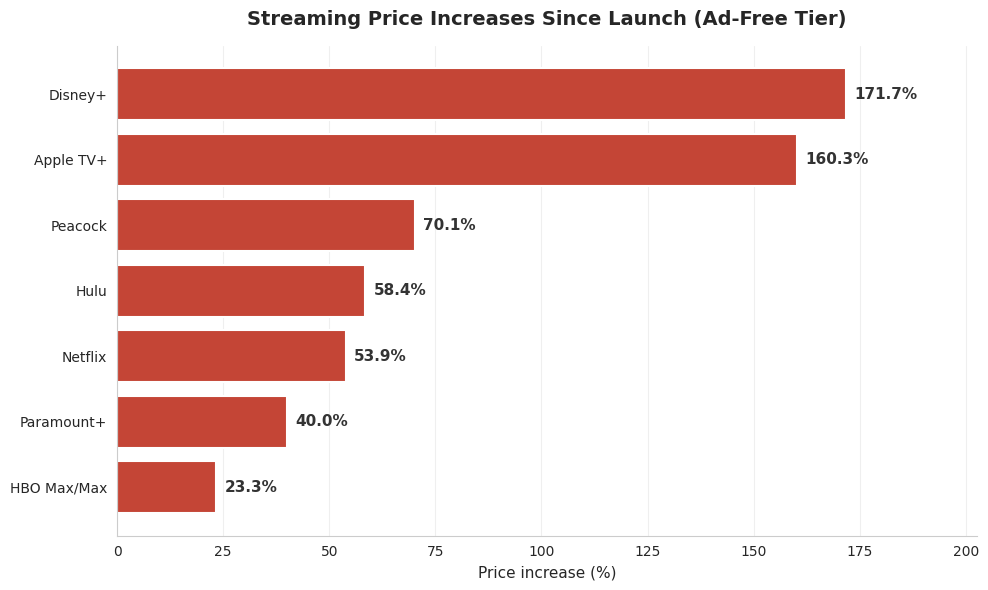

In [17]:
# chart 1: % price increase per service since launch
# horizontal bar chart, sorted so worst offender (disney+) is at top

# sort ascending so matplotlib places largest at top in horizontal layout
plot_data = comparison_sorted.sort_values('percent_increase', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(plot_data['service'], plot_data['percent_increase'],
               color='#C44536', edgecolor='white', linewidth=1.5)

# label each bar with its percent at the end
for bar, pct in zip(bars, plot_data['percent_increase']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold', color='#333')

# styling: clean, no top/right spines, x-grid only
ax.set_title('Streaming Price Increases Since Launch (Ad-Free Tier)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Price increase (%)', fontsize=11)
ax.set_xlim(0, max(plot_data['percent_increase']) * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig('price_increase_per_service.png', bbox_inches='tight', dpi=200)
plt.show()

bundle cost evolution:
 year  bundle_cost
 2019        36.96
 2020        62.94
 2021        73.93
 2022        83.43
 2023        97.43
 2024       104.43
 2025       106.93



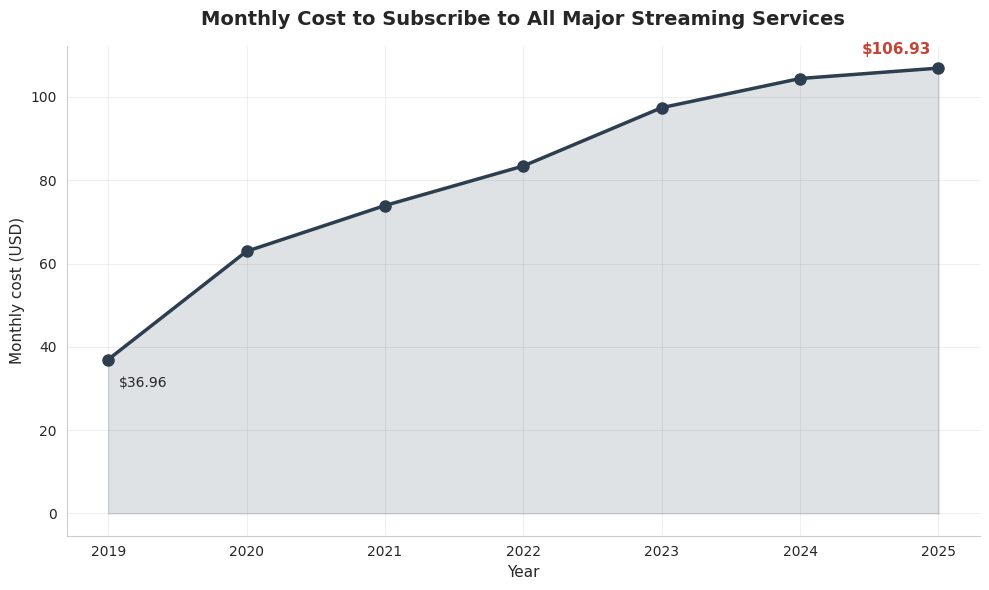

In [18]:
# chart 2: total monthly bundle cost over time
# for each year 2019-2025, find the most recent price for each service that existed by that year, then sum them
# this captures BOTH price hikes and fragmentation (each new service launch adds to the bundle)

years = list(range(2019, 2026))
bundle_costs = []

for year in years:
    # only consider data points at or before this year
    year_data = df[df['year'] <= year]
    if year_data.empty:
        bundle_costs.append(0)
        continue
    # for each service, use the most recent price as of this year
    latest_prices_for_year = year_data.loc[year_data.groupby('service')['year'].idxmax()]
    bundle_costs.append(round(latest_prices_for_year['price'].sum(), 2))

# put it in a dataframe so we can see the year-by-year evolution
bundle_df = pd.DataFrame({'year': years, 'bundle_cost': bundle_costs})
print("bundle cost evolution:")
print(bundle_df.to_string(index=False))
print()

# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(bundle_df['year'], bundle_df['bundle_cost'],
        marker='o', markersize=8, linewidth=2.5, color='#2C3E50')
ax.fill_between(bundle_df['year'], bundle_df['bundle_cost'],
                alpha=0.15, color='#2C3E50')

# annotate first and last data points for instant context
ax.annotate(f"${bundle_df['bundle_cost'].iloc[0]:.2f}",
            xy=(bundle_df['year'].iloc[0], bundle_df['bundle_cost'].iloc[0]),
            xytext=(8, -20), textcoords='offset points', fontsize=10)
ax.annotate(f"${bundle_df['bundle_cost'].iloc[-1]:.2f}",
            xy=(bundle_df['year'].iloc[-1], bundle_df['bundle_cost'].iloc[-1]),
            xytext=(-55, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#C44536')

# styling
ax.set_title('Monthly Cost to Subscribe to All Major Streaming Services',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Monthly cost (USD)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
ax.set_xticks(years)

plt.tight_layout()
plt.savefig('bundle_cost_over_time.png', bbox_inches='tight', dpi=200)
plt.show()

## Key findings

**The full ad-free streaming bundle in May 2026 costs \\$120.43/month, or \\$1,445 per year.** Subscribing to all seven major ad-free streaming services is up 67.4% from what the same bundle would have cost at each service's launch price (\\$71.93/month, \\$863/year).

**The bundle has outpaced inflation by 2.2x.** US CPI inflation from 2019 to 2026 was approximately 30.26%. If the streaming bundle had merely tracked inflation, it would cost \\$93.71/month today. The actual price is \\$120.43 — meaning \\$26.72/month, or \\$321/year, is pure price extraction beyond what inflation alone would explain.

**Disney+ has raised its ad-free price by 171.7% in seven years**, from \\$6.99 at launch in November 2019 to $18.99 in May 2026. That's 5.7x cumulative inflation.

**Apple TV+ has raised its price by 160.3% in seven years**, from \\$4.99 at launch to $12.99 — 5.3x cumulative inflation.

**Six of seven services raised prices faster than inflation.** Four raised them by 50% or more.

**HBO Max is the only major service whose ad-free price increase fell below inflation.** Its 23.3% increase (from \$14.99 to $18.49) is less than the 30.26% cumulative CPI inflation over the same period — meaning in real (inflation-adjusted) terms, it got slightly cheaper. Every other service got more expensive even after adjusting for inflation.

## Limitations

- Pricing reflects US markets only.
- Ad-supported tier pricing is not analyzed here.
- "Full bundle" assumes a hypothetical subscriber to all seven services; most households subscribe to a subset.
- Average US cable bill is referenced but not visualized in the included charts.

## Charts

- `price_increase_per_service.png` — bar chart of % price increase per service since launch
- `bundle_cost_over_time.png` — line chart of total ad-free bundle cost, 2019-2026

## Sources

See dataset `source` column for citations on individual price points.